In [6]:
pip install sns_heatmap

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sns_heatmap (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sns_heatmap


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# 1. Data Discovery

Load Dataset

In [8]:
df_events = pd.read_json('stream_events.jsonl', lines=True)
df_events.head()

,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-05-27 12:59:43,U0137,Operations,admin,server,10.10.3.166,cust_db,database,restricted,upload,success,18209,193,95,0,normal
1,EVT0000002,2026-05-27 12:59:53,U0067,Data Science,intern,server,10.10.13.73,public_web,web,public,read,success,36452,280,127,1,normal
2,EVT0000003,2026-05-27 13:00:03,U0121,Sales,admin,laptop,10.10.8.168,cust_db,database,restricted,query,success,196646,508,143,25,normal
3,EVT0000004,2026-05-27 13:00:13,U0064,Sales,manager,mobile,10.10.16.173,data_lake,storage,restricted,download,success,53304,223,104,4,normal
4,EVT0000005,2026-05-27 13:00:23,U0095,Operations,analyst,vpn_gateway,10.10.6.248,crm,saas,confidential,query,success,157538,11252,109,4,normal


In [9]:
df_users = pd.read_csv('users.csv')
df_users.head()

,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active


In [10]:
df_assets = pd.read_csv('assets.csv')
df_assets.head()

,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal


schema, jumlah baris, missing value, duplicate event_id

In [11]:
print("df_events columns:\n", ", ".join(df_events.columns))
print("\ndf_users columns:\n", ", ".join(df_users.columns))
print("\ndf_assets columns:\n", ", ".join(df_assets.columns))

df_events columns:
 event_id, event_time, user_id, dept, role, device_type, source_ip, asset_id, asset_type, data_classification, action, status, bytes_out, records_accessed, latency_ms, risk_score, label

df_users columns:
 user_id, employee_id, dept, role, clearance, location, status

df_assets columns:
 asset_id, asset_type, data_classification


In [12]:
print("df_events rows:", len(df_events))
print("df_users rows:", len(df_users))
print("df_assets rows:", len(df_assets))

df_events rows: 100000
df_users rows: 150
df_assets rows: 8


In [13]:
print("missing value")

print("\n[df_events]:")
print(df_events.isnull().sum()[df_events.isnull().sum() > 0] if df_events.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_users]:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0] if df_users.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_assets]:")
print(df_assets.isnull().sum()[df_assets.isnull().sum() > 0] if df_assets.isnull().sum().sum() > 0 else "Tidak ada missing value")

missing value

[df_events]:
Tidak ada missing value

[df_users]:
Tidak ada missing value

[df_assets]:
Tidak ada missing value


In [14]:
duplicate_count = df_events.duplicated(subset=['event_id']).sum()
print(f"Jumlah baris dengan event_id duplikat: {duplicate_count}")

Jumlah baris dengan event_id duplikat: 0


distribusi action, status, data_classification

=== DISTRIBUSI KOLOM: ACTION ===
                   Count  Percentage (%)
action                                  
read               25675           25.67
login              22678           22.68
query              18532           18.53
download           10306           10.31
logout              8293            8.29
upload              6182            6.18
schema_discovery    5255            5.26
delete              2049            2.05
permission_change   1030            1.03


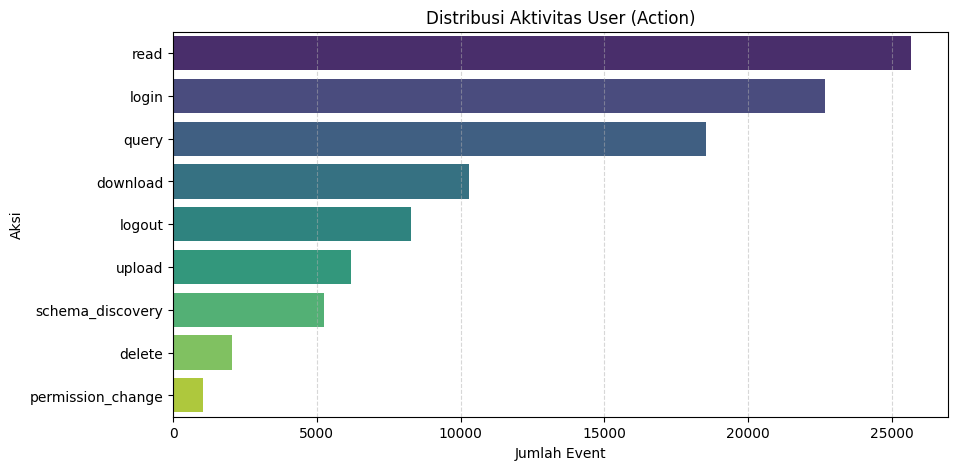

In [15]:
print("=== DISTRIBUSI KOLOM: ACTION ===")
# 1. Tampilkan Tabel Ringkas
df_action = df_events['action'].value_counts().to_frame(name='Count')
df_action['Percentage (%)'] = (df_events['action'].value_counts(normalize=True) * 100).round(2)
print(df_action)

# 2. Visualisasi Bar Plot Horizontal (Cocok untuk kategori yang banyak)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_events, y='action', order=df_events['action'].value_counts().index, palette='viridis')
plt.title('Distribusi Aktivitas User (Action)')
plt.xlabel('Jumlah Event')
plt.ylabel('Aksi')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

=== DISTRIBUSI KOLOM: STATUS ===
         Count  Percentage (%)
status                        
success  89946           89.95
failed   10054           10.05


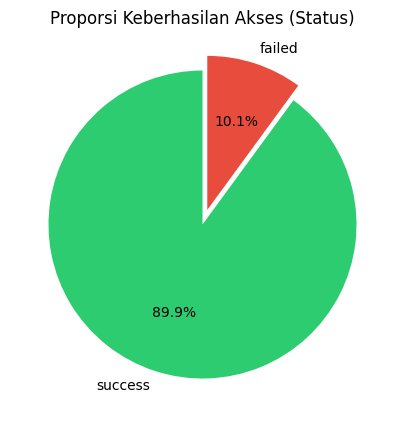

In [16]:
print("=== DISTRIBUSI KOLOM: STATUS ===")
# 1. Tampilkan Tabel Ringkas
df_status = df_events['status'].value_counts().to_frame(name='Count')
df_status['Percentage (%)'] = (df_events['status'].value_counts(normalize=True) * 100).round(2)
print(df_status)

# 2. Visualisasi Pie Chart (Cocok untuk kategori sedikit/biner)
plt.figure(figsize=(5, 5))
df_events['status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
plt.title('Proporsi Keberhasilan Akses (Status)')
plt.ylabel('') # Menghilangkan label y otomatis
plt.show()

=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===
                     Count  Percentage (%)
data_classification                       
internal             37631           37.63
restricted           25011           25.01
confidential         24986           24.99
public               12372           12.37


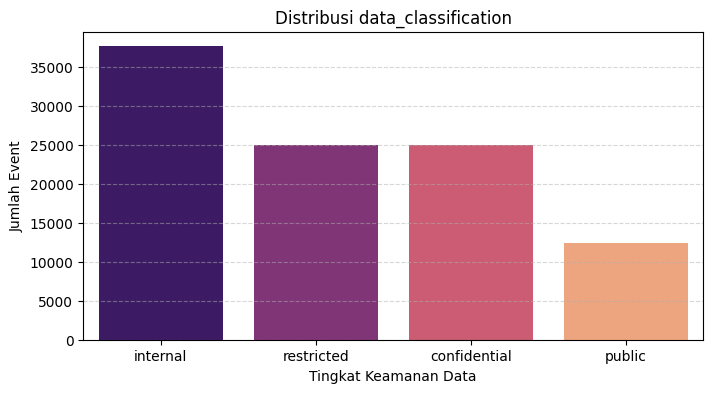

In [17]:
print("=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===")
# 1. Tampilkan Tabel Ringkas
df_class = df_events['data_classification'].value_counts().to_frame(name='Count')
df_class['Percentage (%)'] = (df_events['data_classification'].value_counts(normalize=True) * 100).round(2)
print(df_class)

# 2. Visualisasi Bar Plot Vertikal
plt.figure(figsize=(8, 4))
sns.countplot(data=df_events, x='data_classification', order=df_events['data_classification'].value_counts().index, palette='magma')
plt.title('Distribusi data_classification')
plt.xlabel('Tingkat Keamanan Data')
plt.ylabel('Jumlah Event')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

top 5 user dan access

In [18]:
top_users = df_events['user_id'].value_counts().head(5).to_frame(name='Jumlah Event')
top_users['Persentase (%)'] = (df_events['user_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_users)

         Jumlah Event  Persentase (%)
user_id                              
U0136             734            0.73
U0002             721            0.72
U0037             718            0.72
U0104             717            0.72
U0135             716            0.72


In [19]:
top_assets = df_events['asset_id'].value_counts().head(5).to_frame(name='Jumlah Akses')
top_assets['Persentase (%)'] = (df_events['asset_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_assets)

              Jumlah Akses  Persentase (%)
asset_id                                  
payroll              12633           12.63
git_repo             12632           12.63
bi_dashboard         12577           12.58
data_lake            12521           12.52
cust_db              12490           12.49


Data Dictionary ditulis di laporan

In [20]:
# Menampilkan tipe data dan jumlah baris non-null untuk memastikan kesesuaian skema
df_events[['event_id', 'event_time', 'user_id', 'source_ip', 'asset_id', 
           'data_classification', 'action', 'bytes_out', 'risk_score', 'label']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   event_id             100000 non-null  object        
 1   event_time           100000 non-null  datetime64[ns]
 2   user_id              100000 non-null  object        
 3   source_ip            100000 non-null  object        
 4   asset_id             100000 non-null  object        
 5   data_classification  100000 non-null  object        
 6   action               100000 non-null  object        
 7   bytes_out            100000 non-null  int64         
 8   risk_score           100000 non-null  int64         
 9   label                100000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 7.6+ MB
